# <font color='black'>**Machine Learning Laboratory**</font>
## <font color='blue'>**Decision Trees — Classification, Regression, Pruning and Multivariate Splits**</font>

This notebook contains two parts:

1. **Detailed Teaching / Sample Part** — theory, equations, numerical examples, categorical examples, Classification Trees, Regression Trees, pruning, and multivariate-tree intuition.
2. **Laboratory Assignment** — a structured, hands-on assignment following the same task-based laboratory format.




### <font color='black'>**Learning Objectives**</font>

After completing this session, students will be able to:

1. Explain root, internal, branch, and leaf nodes.
2. Explain how a Decision Tree recursively partitions data.
3. Calculate **Gini impurity**.
4. Calculate **Entropy** and **Information Gain**.
5. Search candidate split thresholds for numerical variables.
6. Evaluate categorical feature splits and trace them to leaf nodes.
7. Train and interpret classification trees using both Gini and Entropy.
8. Explain how a **Regression Tree** selects splits and predicts at leaves.
9. Apply common **pre-pruning** controls.
10. Apply **post-pruning** using cost-complexity pruning.



### **Session Outline**

1. Decision Tree intuition and terminology.
2. Gini impurity.
3. Entropy and Information Gain.
4. Numerical split selection with a complete worked example.
5. Recursive tree construction and leaf formation.
6. Categorical feature splitting with a complete worked example.
7. Classification Tree using the Iris dataset.
8. Gini vs Information Gain (Entropy-based) comparison.
9. Pre-pruning.
10. Post-pruning / Cost-Complexity Pruning.
11. Regression Tree mathematics and worked example.
12. Regression Tree using Scikit-learn.
13. Laboratory assignment.


# <font color='red'>**Part A — Detailed Decision Tree Tutorial and Worked Example**</font>

## <font color='red'>**1. What is a Decision Tree?**</font>

A **Decision Tree** is a supervised learning model that repeatedly divides the data into smaller groups by asking simple questions about the input features.

For classification, each question typically has the form

$$
x_j \le t,
$$

where $x_j$ is a feature and $t$ is a threshold.

| Component | Meaning |
|---|---|
| **Root node** | First node containing the complete training set |
| **Internal / decision node** | A feature-threshold test |
| **Branch** | Outcome of the test |
| **Leaf node** | Final class prediction |
| **Depth** | Number of edges from the root to a node |

A simple conceptual tree may look like:

```text
                     Study Hours <= 2.75?
                      /                \
                   Yes                  No
                  /                      \
          Mostly "Fail"              Mostly "Pass"
```

The learning problem is therefore:

> **Which feature and which threshold should be selected at every node?**

## <font color='red'>**2. How Does a Decision Tree Learn?**</font>

At each non-leaf node, the algorithm performs the following steps:

1. Consider candidate features.
2. Generate candidate split thresholds.
3. Divide the current samples into left and right groups.
4. Measure the impurity of the parent node.
5. Measure the weighted impurity after the split.
6. Calculate the reduction in impurity.
7. Select the split producing the largest reduction.
8. Repeat the process recursively for each child node.

A good split creates child nodes that are **more homogeneous** than the parent node.

### **Stopping conditions**

Tree growth must eventually stop. Common conditions include:

- all samples in the node belong to the same class;
- the maximum tree depth has been reached;
- the node contains fewer than `min_samples_split` observations;
- a child would contain too few samples;
- no candidate split produces a useful reduction in impurity.

When splitting stops, the node becomes a **leaf**, usually predicting the majority class present in that node.

## <font color='red'>**3. Measuring Node Impurity**</font>

Assume a node contains $K$ classes and $p_k$ is the proportion of class $k$.

### **3.1 Entropy**

$$
H(S)=-\sum_{k=1}^{K}p_k\log_2(p_k)
$$

Interpretation:

- $H(S)=0$: the node is pure.
- Larger entropy: the classes are more mixed.

For binary classification, maximum entropy occurs when both classes have equal probability.

### **3.2 Gini Impurity**

$$
G(S)=1-\sum_{k=1}^{K}p_k^2
$$

Interpretation:

- $G(S)=0$: the node is pure.
- Larger Gini impurity: greater class mixing.

### **3.3 Weighted Impurity After a Split**

Suppose parent set $S$ is divided into left child $S_L$ and right child $S_R$:

$$
I_{\text{split}}
=
\frac{|S_L|}{|S|}I(S_L)
+
\frac{|S_R|}{|S|}I(S_R).
$$

### **3.4 Information Gain / Impurity Reduction**

$$
IG
=
I(S)-I_{\text{split}}.
$$

The preferred split is the one with the **largest impurity reduction**.

In [2]:
# Import packages used in the teaching examples
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    plot_tree,
    export_text
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

RANDOM_STATE = 42
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", 50)


## <font color='red'>**4. Detailed Numerical Example: Choosing the Best Split**</font>

Consider a small dataset in which we want to predict whether a student will **Pass (1)** or **Fail (0)** using only the number of hours studied.

| Student | Study Hours | Class |
|---:|---:|---:|
| 1 | 1.0 | 0 |
| 2 | 1.5 | 0 |
| 3 | 2.0 | 1 |
| 4 | 2.5 | 0 |
| 5 | 3.0 | 1 |
| 6 | 3.5 | 1 |
| 7 | 4.0 | 1 |
| 8 | 4.5 | 1 |

The root contains:

- Fail $=3$
- Pass $=5$
- Total $=8$

Therefore,

$$
p_{\text{Fail}}=\frac{3}{8},
\qquad
p_{\text{Pass}}=\frac{5}{8}.
$$

### **Parent Entropy**

$$
H(S)
=
-\frac{3}{8}\log_2\frac{3}{8}
-\frac{5}{8}\log_2\frac{5}{8}
\approx 0.9544.
$$

### **Parent Gini Impurity**

$$
G(S)
=
1-\left(\frac{3}{8}\right)^2-\left(\frac{5}{8}\right)^2
=
0.46875.
$$

Now suppose we test the threshold

$$
\text{Study Hours} \le 2.75.
$$

The split becomes:

- **Left:** $[0,0,1,0]$ — three Fail and one Pass
- **Right:** $[1,1,1,1]$ — four Pass

For the left node,

$$
H(S_L)
=
-\frac34\log_2\frac34-\frac14\log_2\frac14
\approx 0.8113.
$$

The right node is pure, therefore

$$
H(S_R)=0.
$$

The weighted entropy is

$$
H_{\text{split}}
=
\frac48(0.8113)+\frac48(0)
=
0.4056.
$$

Hence,

$$
IG
=
0.9544-0.4056
=
0.5488.
$$

A real Decision Tree does not evaluate only this threshold. It evaluates **many candidate thresholds** and chooses the best one.

In [3]:
# Create the toy dataset used above
toy_df = pd.DataFrame({
    "study_hours": [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5],
    "class":       [0,   0,   1,   0,   1,   1,   1,   1]
})

toy_df

,study_hours,class
0,1.0,0
1,1.5,0
2,2.0,1
3,2.5,0
4,3.0,1
5,3.5,1
6,4.0,1
7,4.5,1


### **Implement the impurity functions**

The following functions are deliberately written from scratch so that the mathematical quantities can be verified directly.

In [4]:
def class_probabilities(y):
    """Return empirical class probabilities."""
    if len(y) == 0:
        return np.array([])
    _, counts = np.unique(y, return_counts=True)
    return counts / counts.sum()


def entropy(y):
    """Calculate entropy of class labels."""
    p = class_probabilities(y)
    if len(p) == 0:
        return 0.0
    return -np.sum(p * np.log2(p))


def gini_impurity(y):
    """Calculate Gini impurity of class labels."""
    p = class_probabilities(y)
    if len(p) == 0:
        return 0.0
    return 1.0 - np.sum(p ** 2)


def impurity_reduction(parent, left, right, criterion="entropy"):
    """Calculate impurity reduction created by a binary split."""
    if len(left) == 0 or len(right) == 0:
        return 0.0

    impurity_fn = entropy if criterion == "entropy" else gini_impurity

    n = len(parent)
    weighted_child_impurity = (
        (len(left) / n) * impurity_fn(left)
        + (len(right) / n) * impurity_fn(right)
    )

    return impurity_fn(parent) - weighted_child_impurity


y_toy = toy_df["class"].to_numpy()

print(f"Parent entropy       : {entropy(y_toy):.4f}")
print(f"Parent Gini impurity : {gini_impurity(y_toy):.4f}")

Parent entropy       : 0.9544
Parent Gini impurity : 0.4688


In [5]:
# Verify the worked threshold: study_hours <= 2.75
threshold = 2.75
x_toy = toy_df["study_hours"].to_numpy()

left_y = y_toy[x_toy <= threshold]
right_y = y_toy[x_toy > threshold]

print("Left labels :", left_y)
print("Right labels:", right_y)
print(f"Left entropy : {entropy(left_y):.4f}")
print(f"Right entropy: {entropy(right_y):.4f}")
print(f"Entropy-based information gain: "
      f"{impurity_reduction(y_toy, left_y, right_y, 'entropy'):.4f}")
print(f"Gini impurity reduction       : "
      f"{impurity_reduction(y_toy, left_y, right_y, 'gini'):.4f}")

Left labels : [0 0 1 0]
Right labels: [1 1 1 1]
Left entropy : 0.8113
Right entropy: -0.0000
Entropy-based information gain: 0.5488
Gini impurity reduction       : 0.2812


## <font color='red'>**5. How Are Candidate Thresholds Generated?**</font>

For a numerical feature, a simple strategy is:

1. sort the unique feature values;
2. take the midpoint between every pair of consecutive values;
3. evaluate every midpoint.

For values

$$
1.0,\;1.5,\;2.0,\;2.5,\;3.0,\ldots
$$

candidate thresholds include

$$
1.25,\;1.75,\;2.25,\;2.75,\ldots
$$

The next cell evaluates every possible threshold in the toy dataset.

In [6]:
def candidate_thresholds(x):
    unique_values = np.sort(np.unique(x))
    return (unique_values[:-1] + unique_values[1:]) / 2


rows = []

for threshold in candidate_thresholds(x_toy):
    left_y = y_toy[x_toy <= threshold]
    right_y = y_toy[x_toy > threshold]

    rows.append({
        "threshold": threshold,
        "left_samples": len(left_y),
        "right_samples": len(right_y),
        "entropy_gain": impurity_reduction(
            y_toy, left_y, right_y, criterion="entropy"
        ),
        "gini_gain": impurity_reduction(
            y_toy, left_y, right_y, criterion="gini"
        )
    })

split_table = pd.DataFrame(rows)
split_table

,threshold,left_samples,right_samples,entropy_gain,gini_gain
0,1.25,1,7,0.199204,0.111607
1,1.75,2,6,0.466917,0.260417
2,2.25,3,5,0.158868,0.102083
3,2.75,4,4,0.548795,0.281250
4,3.25,5,3,0.347590,0.168750
5,3.75,6,2,0.204434,0.093750
6,4.25,7,1,0.092359,0.040179


In [7]:
best_entropy_row = split_table.loc[split_table["entropy_gain"].idxmax()]
best_gini_row = split_table.loc[split_table["gini_gain"].idxmax()]

print("Best threshold using Entropy:")
print(best_entropy_row.to_string())

print("\nBest threshold using Gini:")
print(best_gini_row.to_string())

Best threshold using Entropy:
threshold        2.750000
left_samples     4.000000
right_samples    4.000000
entropy_gain     0.548795
gini_gain        0.281250

Best threshold using Gini:
threshold        2.750000
left_samples     4.000000
right_samples    4.000000
entropy_gain     0.548795
gini_gain        0.281250


### **What happened?**

The algorithm did not *know* in advance that $2.75$ was a useful threshold.

It:

1. generated possible thresholds;
2. created left and right subsets for every threshold;
3. calculated impurity reduction;
4. selected the threshold producing the largest reduction.

A full Decision Tree performs the same search **again inside each child node**.

## <font color='red'>**6. From One Split to a Complete Tree**</font>

After selecting the best split at the root:

```text
build_tree(samples, depth):

    if stopping_condition_is_true:
        return Leaf(majority_class)

    best_feature, best_threshold = find_best_split(samples)

    left_samples  = samples[best_feature <= best_threshold]
    right_samples = samples[best_feature >  best_threshold]

    left_child  = build_tree(left_samples,  depth + 1)
    right_child = build_tree(right_samples, depth + 1)

    return DecisionNode(
        feature=best_feature,
        threshold=best_threshold,
        left=left_child,
        right=right_child
    )
```

This is a **recursive algorithm**.

### Typical stopping conditions

A node becomes a leaf when one or more of the following occurs:

- all labels are identical;
- `depth >= max_depth`;
- `number_of_samples < min_samples_split`;
- no valid split is available;
- the best impurity reduction is zero or too small.

### Leaf prediction

For a classification tree, a simple leaf prediction is

$$
\hat y_{\text{leaf}}
=
\arg\max_k N_k,
$$

where $N_k$ is the number of training observations belonging to class $k$ in that leaf.

## <font color='red'>**7. Complete Example Using the Iris Dataset**</font>

We now use Scikit-learn to see how the complete process appears in practice.

The Iris dataset contains four numerical features:

- sepal length
- sepal width
- petal length
- petal width

and three target classes:

- setosa
- versicolor
- virginica

Decision Trees generally **do not require feature standardization**, because a threshold comparison such as

$$
x_j \le t
$$

depends on ordering rather than Euclidean distance.

In [8]:
iris = load_iris()

X = iris.data
y = iris.target

iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df["target"] = y
iris_df["class_name"] = [iris.target_names[i] for i in y]

print(iris_df.head().to_string(index=False))
print("\nShape:", iris_df.shape)
print("Feature names:", list(iris.feature_names))
print("Class names:", list(iris.target_names))

class_counts = iris_df["class_name"].value_counts()
print("\nClass distribution:")
print(class_counts.to_string())

 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  target class_name
               5.1               3.5                1.4               0.2       0     setosa
               4.9               3.0                1.4               0.2       0     setosa
               4.7               3.2                1.3               0.2       0     setosa
               4.6               3.1                1.5               0.2       0     setosa
               5.0               3.6                1.4               0.2       0     setosa

Shape: (150, 6)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class names: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Class distribution:
class_name
setosa        50
versicolor    50
virginica     50


### **Train–Validation–Test Split**

We use:

- **70% training**
- **15% validation**
- **15% test**

The validation set is used for model selection.  
The test set remains untouched until the final model has been selected.

In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Training samples  :", len(y_train))
print("Validation samples:", len(y_val))
print("Test samples      :", len(y_test))

Training samples  : 105
Validation samples: 22
Test samples      : 23


## <font color='red'>**8. Train a Baseline Decision Tree**</font>

Here we use:

- `criterion="entropy"` — split quality is measured with entropy;
- `max_depth=3` — the tree cannot grow beyond depth 3;
- `min_samples_split=2` — at least two samples are needed to attempt a split.

In [10]:
baseline_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    min_samples_split=2,
    random_state=RANDOM_STATE
)

baseline_tree.fit(X_train, y_train)

train_pred = baseline_tree.predict(X_train)
val_pred = baseline_tree.predict(X_val)

print(f"Training accuracy  : {accuracy_score(y_train, train_pred):.4f}")
print(f"Validation accuracy: {accuracy_score(y_val, val_pred):.4f}")
print("Tree depth         :", baseline_tree.get_depth())
print("Number of leaves   :", baseline_tree.get_n_leaves())

Training accuracy  : 0.9810
Validation accuracy: 0.9545
Tree depth         : 3
Number of leaves   : 5


## <font color='red'>**9. Visualize the Learned Tree**</font>

The visualization exposes the actual questions learned from the data.

Within each node, Scikit-learn displays information such as:

- splitting rule;
- impurity;
- number of samples;
- class counts;
- predicted class.

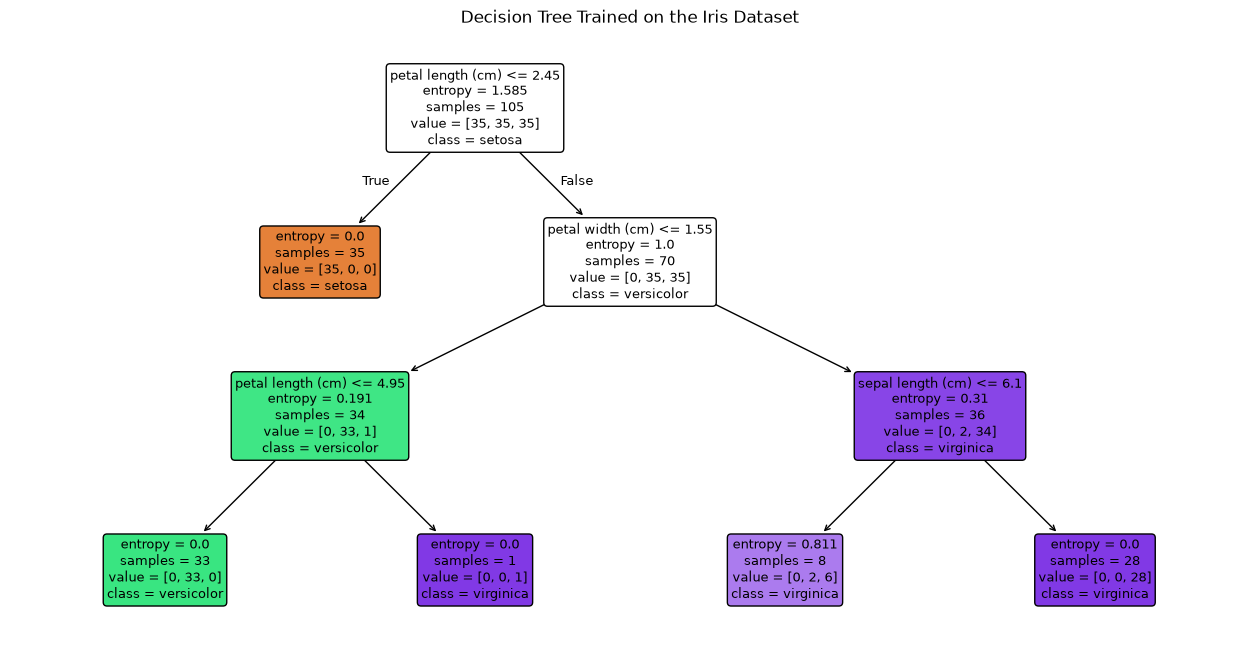

In [11]:
plt.figure(figsize=(16, 8))
plot_tree(
    baseline_tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree Trained on the Iris Dataset")
plt.show()

### **Print the Decision Rules**

A tree can also be represented as human-readable nested `if-else` rules.

In [12]:
rules = export_text(
    baseline_tree,
    feature_names=list(iris.feature_names)
)

print(rules)

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.55
|   |   |--- sepal length (cm) <= 6.10
|   |   |   |--- class: 2
|   |   |--- sepal length (cm) >  6.10
|   |   |   |--- class: 2



## <font color='red'>**10. Follow the Decision Path of One Sample**</font>

Prediction is simply a sequence of feature-threshold comparisons from the root to a leaf.

The next cell selects one validation sample and prints every decision used to classify it.

In [13]:
sample_index = 0
sample = X_val[sample_index].reshape(1, -1)
true_class = y_val[sample_index]
predicted_class = baseline_tree.predict(sample)[0]

node_indicator = baseline_tree.decision_path(sample)
leaf_id = baseline_tree.apply(sample)[0]

feature = baseline_tree.tree_.feature
threshold = baseline_tree.tree_.threshold

print("Sample:")
for name, value in zip(iris.feature_names, sample.ravel()):
    print(f"  {name:20s} = {value:.3f}")

print("\nDecision path:")

for node_id in node_indicator.indices:
    if node_id == leaf_id:
        print(f"  Node {node_id}: LEAF")
        continue

    feature_index = feature[node_id]
    feature_value = sample[0, feature_index]
    threshold_value = threshold[node_id]

    direction = "<=" if feature_value <= threshold_value else ">"

    print(
        f"  Node {node_id}: "
        f"{iris.feature_names[feature_index]} = {feature_value:.3f} "
        f"{direction} {threshold_value:.3f}"
    )

print("\nTrue class     :", iris.target_names[true_class])
print("Predicted class:", iris.target_names[predicted_class])

Sample:
  sepal length (cm)    = 6.700
  sepal width (cm)     = 3.000
  petal length (cm)    = 5.000
  petal width (cm)     = 1.700

Decision path:
  Node 0: petal length (cm) = 5.000 > 2.450
  Node 2: petal width (cm) = 1.700 > 1.550
  Node 6: sepal length (cm) = 6.700 > 6.100
  Node 8: LEAF

True class     : versicolor
Predicted class: virginica


## <font color='red'>**11. Tree Depth: Underfitting and Overfitting**</font>

Tree depth controls model complexity.

### **Very shallow tree**

A tree with insufficient depth may be unable to represent the important decision boundaries.

This is **underfitting**.

### **Very deep tree**

A highly flexible tree may memorize small irregularities in the training data.

This is **overfitting**.

A common pattern is:

- training accuracy keeps increasing;
- validation accuracy increases initially;
- after some point, validation accuracy may stop improving or decrease.

The appropriate depth should therefore be selected using **validation data**, not test data.

In [14]:
depth_results = []

for depth in range(1, 11):
    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=RANDOM_STATE
    )
    model.fit(X_train, y_train)

    depth_results.append({
        "max_depth": depth,
        "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
        "validation_accuracy": accuracy_score(y_val, model.predict(X_val)),
        "leaves": model.get_n_leaves()
    })

depth_df = pd.DataFrame(depth_results)
depth_df

,max_depth,train_accuracy,validation_accuracy,leaves
0,1,0.666667,0.681818,2
1,2,0.971429,0.909091,3
2,3,0.980952,0.954545,5
3,4,0.990476,0.909091,6
4,5,0.990476,0.909091,7
5,6,1.000000,0.909091,8
6,7,1.000000,0.909091,8
7,8,1.000000,0.909091,8
8,9,1.000000,0.909091,8
9,10,1.000000,0.909091,8


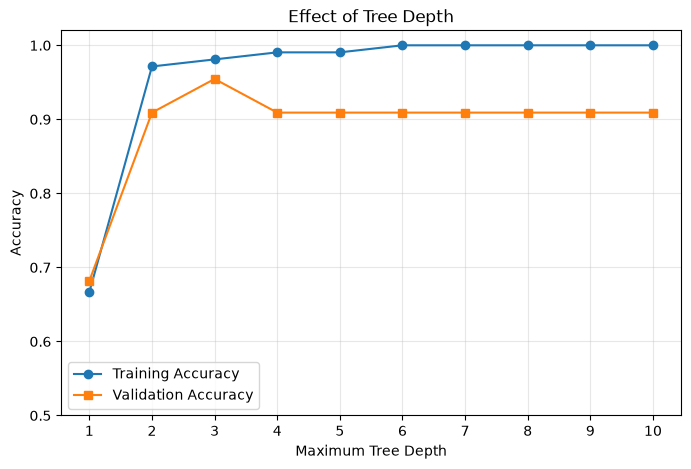

Best depth based on validation accuracy: 3


In [15]:
plt.figure(figsize=(8, 5))
plt.plot(
    depth_df["max_depth"],
    depth_df["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)
plt.plot(
    depth_df["max_depth"],
    depth_df["validation_accuracy"],
    marker="s",
    label="Validation Accuracy"
)
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Effect of Tree Depth")
plt.xticks(depth_df["max_depth"])
plt.ylim(0.5, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

best_depth = int(
    depth_df.loc[depth_df["validation_accuracy"].idxmax(), "max_depth"]
)
print("Best depth based on validation accuracy:", best_depth)

## <font color='red'>**12. Gini Impurity versus Entropy**</font>

Both criteria attempt to produce purer child nodes.

They often produce similar trees, although the exact split sequence can differ.

The correct way to compare them is empirically on validation data.

In [16]:
criterion_results = []

for criterion in ["gini", "entropy"]:
    model = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=best_depth,
        random_state=RANDOM_STATE
    )
    model.fit(X_train, y_train)

    criterion_results.append({
        "criterion": criterion,
        "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
        "validation_accuracy": accuracy_score(y_val, model.predict(X_val)),
        "depth": model.get_depth(),
        "leaves": model.get_n_leaves()
    })

criterion_df = pd.DataFrame(criterion_results)
criterion_df

,criterion,train_accuracy,validation_accuracy,depth,leaves
0,gini,0.980952,0.954545,3,5
1,entropy,0.980952,0.954545,3,5


## <font color='red'>**13. Feature Importance**</font>

A Decision Tree can report **impurity-based feature importance**.

A feature receives greater importance when it contributes more weighted impurity reduction across the fitted tree.

These values are useful for interpretation, but they should **not automatically be interpreted as causal effects**.

In [17]:
selected_criterion = criterion_df.sort_values(
    ["validation_accuracy", "leaves"],
    ascending=[False, True]
).iloc[0]["criterion"]

selected_tree = DecisionTreeClassifier(
    criterion=selected_criterion,
    max_depth=best_depth,
    random_state=RANDOM_STATE
)
selected_tree.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "feature": iris.feature_names,
    "importance": selected_tree.feature_importances_
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
2,petal length (cm),0.550877
3,petal width (cm),0.449123
1,sepal width (cm),0.000000
0,sepal length (cm),0.000000


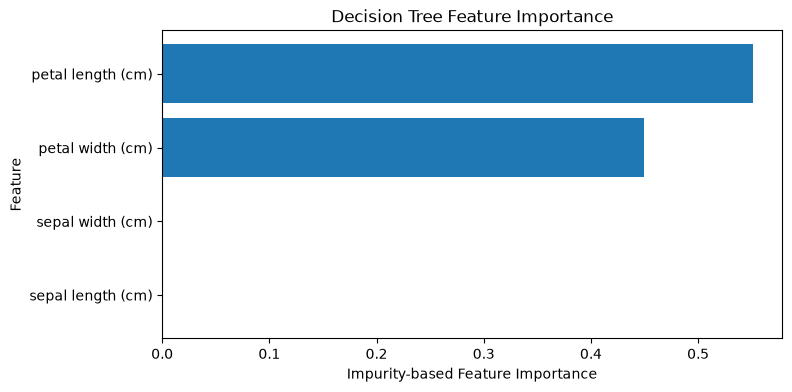

In [18]:
plt.figure(figsize=(8, 4))
plt.barh(
    importance_df["feature"][::-1],
    importance_df["importance"][::-1]
)
plt.xlabel("Impurity-based Feature Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")
plt.show()

## <font color='red'>**14. Final Evaluation on the Test Set**</font>

Only after depth and criterion have been selected using validation data do we evaluate the final tree on the untouched test set.

In [19]:
test_pred = selected_tree.predict(X_test)

print("Selected criterion:", selected_criterion)
print("Selected max_depth:", best_depth)
print(f"Test accuracy       : {accuracy_score(y_test, test_pred):.4f}")
print(f"Macro precision     : {precision_score(y_test, test_pred, average='macro'):.4f}")
print(f"Macro recall        : {recall_score(y_test, test_pred, average='macro'):.4f}")
print(f"Macro F1-score      : {f1_score(y_test, test_pred, average='macro'):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test, test_pred,
    target_names=iris.target_names,
    zero_division=0
))

Selected criterion: gini
Selected max_depth: 3
Test accuracy       : 1.0000
Macro precision     : 1.0000
Macro recall        : 1.0000
Macro F1-score      : 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       1.00      1.00      1.00         8
   virginica       1.00      1.00      1.00         8

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



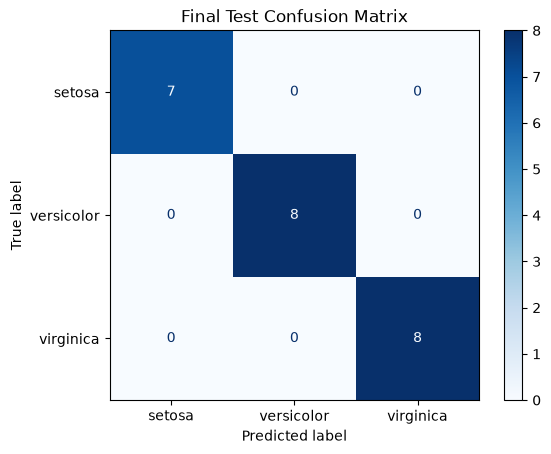

In [20]:
cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Final Test Confusion Matrix")
plt.show()

### **Important Lessons from the Sample**

1. A Decision Tree learns by repeatedly selecting feature-threshold splits.
2. Entropy and Gini quantify class impurity.
3. The best split maximizes impurity reduction.
4. The same split-selection procedure is applied recursively.
5. Tree depth controls model complexity.
6. Very shallow trees may underfit.
7. Very deep trees may overfit.
8. Decision Trees generally do not require feature scaling.
9. Validation data should be used for model selection.
10. The test set should remain untouched until the final evaluation.
11. Tree rules can be inspected directly.
12. Feature importance provides a useful, but non-causal, interpretation of the fitted model.

# <font color='red'>**15. Gini vs Information Gain: Correct Interpretation**</font>

Before moving further, keep the terminology precise:

- **Gini impurity** is itself an impurity measure.
- **Entropy** is another impurity measure.
- **Information Gain** is the reduction in Entropy created by a split.

Therefore, when we say that a tree uses **Information Gain**, the split is selected by maximizing

$$
IG
=
H(S)-H_{\text{split}}.
$$

In Scikit-learn, this corresponds to

```python
DecisionTreeClassifier(criterion="entropy")
```

because the model internally compares entropy reductions.

So in this notebook we will use the teaching terminology:

> **Criterion 1: Gini impurity**  
> **Criterion 2: Information Gain (Entropy-based)**

# <font color='red'>**16. Categorical Data: How a Tree Reaches Leaf Nodes**</font>

A numerical feature can be split using a threshold such as

$$
x_j \le t.
$$

A categorical feature is different because values such as `Sunny`, `Rain`, and `Overcast` do not have a natural numerical ordering.

To understand categorical splitting clearly, consider the classic **Play Tennis** dataset.

The target is `Play`, with classes `Yes` and `No`.

In [21]:
play_tennis = pd.DataFrame({
    "Outlook": [
        "Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast",
        "Sunny","Sunny","Rain","Sunny","Overcast","Overcast","Rain"
    ],
    "Temperature": [
        "Hot","Hot","Hot","Mild","Cool","Cool","Cool",
        "Mild","Cool","Mild","Mild","Mild","Hot","Mild"
    ],
    "Humidity": [
        "High","High","High","High","Normal","Normal","Normal",
        "High","Normal","Normal","Normal","High","Normal","High"
    ],
    "Wind": [
        "Weak","Strong","Weak","Weak","Weak","Strong","Strong",
        "Weak","Weak","Weak","Strong","Strong","Weak","Strong"
    ],
    "Play": [
        "No","No","Yes","Yes","Yes","No","Yes",
        "No","Yes","Yes","Yes","Yes","Yes","No"
    ]
})

play_tennis

,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


## **16.1 Parent Entropy**

The complete dataset contains:

- `Yes` = 9
- `No` = 5

Hence,

$$
p_{\text{Yes}}=\frac{9}{14},
\qquad
p_{\text{No}}=\frac{5}{14}.
$$

The parent entropy is

$$
H(S)
=
-\frac{9}{14}\log_2\frac{9}{14}
-\frac{5}{14}\log_2\frac{5}{14}
\approx 0.9403.
$$

In [22]:
print(play_tennis["Play"].value_counts())
print(f"Parent entropy = {entropy(play_tennis['Play']):.4f}")

Play
Yes    9
No     5
Name: count, dtype: int64
Parent entropy = 0.9403


## **16.2 Information Gain for a Categorical Feature**

Suppose feature $A$ has categories $v_1,v_2,\ldots,v_m$.

The weighted entropy after splitting on $A$ is

$$
H_{\mathrm{split}}(A)
=
\sum_{r=1}^{m}
\frac{|S_r|}{|S|}
H(S_r).
$$

Then

$$
IG(S,A)
=
H(S)-H_{\mathrm{split}}(A).
$$

For `Outlook`, the branches are:

- Sunny
- Overcast
- Rain

In [23]:
def categorical_information_gain(df, feature, target):
    parent_entropy = entropy(df[target])
    total = len(df)
    weighted_entropy = 0.0
    details = []

    for value, group in df.groupby(feature):
        group_entropy = entropy(group[target])
        weight = len(group) / total
        weighted_entropy += weight * group_entropy

        details.append({
            "Feature": feature,
            "Category": value,
            "Samples": len(group),
            "Entropy": group_entropy,
            "Weight": weight
        })

    information_gain = parent_entropy - weighted_entropy
    return information_gain, weighted_entropy, pd.DataFrame(details)


ig_outlook, weighted_outlook, outlook_details = categorical_information_gain(
    play_tennis, "Outlook", "Play"
)

outlook_details

,Feature,Category,Samples,Entropy,Weight
0,Outlook,Overcast,4,-0.000000,0.285714
1,Outlook,Rain,5,0.970951,0.357143
2,Outlook,Sunny,5,0.970951,0.357143


In [24]:
print(f"Parent entropy             = {entropy(play_tennis['Play']):.4f}")
print(f"Weighted Outlook entropy   = {weighted_outlook:.4f}")
print(f"Information Gain (Outlook) = {ig_outlook:.4f}")

Parent entropy             = 0.9403
Weighted Outlook entropy   = 0.6935
Information Gain (Outlook) = 0.2467


## **16.3 Compare All Candidate Categorical Features**

The tree evaluates every candidate feature and selects the one with the largest Information Gain.

In [25]:
categorical_features = ["Outlook", "Temperature", "Humidity", "Wind"]

rows = []
for feature in categorical_features:
    ig, weighted_ent, _ = categorical_information_gain(
        play_tennis, feature, "Play"
    )
    rows.append({
        "Feature": feature,
        "Weighted_Entropy": weighted_ent,
        "Information_Gain": ig
    })

categorical_ig_table = pd.DataFrame(rows).sort_values(
    "Information_Gain",
    ascending=False
)

categorical_ig_table

,Feature,Weighted_Entropy,Information_Gain
0,Outlook,0.693536,0.246750
2,Humidity,0.788450,0.151836
3,Wind,0.892159,0.048127
1,Temperature,0.911063,0.029223


For this dataset, `Outlook` gives the largest Information Gain at the root.

So the first question is conceptually

```text
Outlook?
|-- Sunny
|-- Overcast
|-- Rain
```

We now inspect each branch separately.

In [26]:
for value, group in play_tennis.groupby("Outlook"):
    print("\nOutlook =", value)
    print(group[["Humidity", "Wind", "Play"]].to_string(index=False))
    print("Class counts:")
    print(group["Play"].value_counts().to_string())


Outlook = Overcast
Humidity   Wind Play
    High   Weak  Yes
  Normal Strong  Yes
    High Strong  Yes
  Normal   Weak  Yes
Class counts:
Play
Yes    4

Outlook = Rain
Humidity   Wind Play
    High   Weak  Yes
  Normal   Weak  Yes
  Normal Strong   No
  Normal   Weak  Yes
    High Strong   No
Class counts:
Play
Yes    3
No     2

Outlook = Sunny
Humidity   Wind Play
    High   Weak   No
    High Strong   No
    High   Weak   No
  Normal   Weak  Yes
  Normal Strong  Yes
Class counts:
Play
No     3
Yes    2


## **16.4 Branch: Outlook = Overcast**

Every observation in this branch has class `Yes`.

Therefore,

$$
H(\text{Overcast})=0.
$$

Because the node is pure, it becomes a leaf:

```text
Outlook = Overcast -> Play = Yes
```

## **16.5 Branch: Outlook = Sunny**

The Sunny subset is mixed, so another split is required.

We calculate Information Gain again, but **only inside the Sunny subset**.

In [27]:
sunny = play_tennis[play_tennis["Outlook"] == "Sunny"].copy()

sunny_rows = []
for feature in ["Temperature", "Humidity", "Wind"]:
    ig, weighted_ent, _ = categorical_information_gain(
        sunny, feature, "Play"
    )
    sunny_rows.append({
        "Feature": feature,
        "Weighted_Entropy": weighted_ent,
        "Information_Gain": ig
    })

pd.DataFrame(sunny_rows).sort_values("Information_Gain", ascending=False)

,Feature,Weighted_Entropy,Information_Gain
1,Humidity,0.000000,0.970951
0,Temperature,0.400000,0.570951
2,Wind,0.950978,0.019973


For the Sunny branch, `Humidity` perfectly separates the classes:

```text
Outlook = Sunny
|
|-- Humidity = High   -> No
|
|-- Humidity = Normal -> Yes
```

Both children are pure leaves.

## **16.6 Branch: Outlook = Rain**

The Rain subset is also mixed, so the same procedure is repeated.

In [28]:
rain = play_tennis[play_tennis["Outlook"] == "Rain"].copy()

rain_rows = []
for feature in ["Temperature", "Humidity", "Wind"]:
    ig, weighted_ent, _ = categorical_information_gain(
        rain, feature, "Play"
    )
    rain_rows.append({
        "Feature": feature,
        "Weighted_Entropy": weighted_ent,
        "Information_Gain": ig
    })

pd.DataFrame(rain_rows).sort_values("Information_Gain", ascending=False)

,Feature,Weighted_Entropy,Information_Gain
2,Wind,0.000000,0.970951
0,Temperature,0.950978,0.019973
1,Humidity,0.950978,0.019973


For the Rain branch, `Wind` separates the observations:

```text
Outlook = Rain
|
|-- Wind = Weak   -> Yes
|
|-- Wind = Strong -> No
```

The complete categorical tree is:

```text
                         Outlook
             _____________|_____________
            /             |             \
         Sunny         Overcast          Rain
           |              |               |
       Humidity           Yes             Wind
       /      \                         /      \
     High    Normal                    Weak    Strong
      |        |                        |        |
      No      Yes                      Yes       No
```

This is the full recursive idea:

> **measure impurity → choose the best split → create branches → inspect impure branches → split again → stop at leaves**

## **16.7 Important Implementation Note: ID3-Style vs CART**

The categorical example above uses a **multiway split**, which is useful for understanding ID3-style learning.

CART-style trees are normally binary:

$$
S\rightarrow S_L,S_R.
$$

For numerical data:

$$
x_j\le t
\quad\text{versus}\quad
x_j>t.
$$

For categorical data, a binary split can conceptually be

$$
x_j\in A
\quad\text{versus}\quad
x_j\notin A,
$$

where $A$ is a subset of categories.

Scikit-learn's standard Decision Tree implementation expects numerical features. Raw strings such as `"Sunny"` or `"Rain"` must therefore be encoded before they are passed to the estimator.

# <font color='red'>**17. Pre-Pruning**</font>

A Decision Tree can continue splitting until very small leaves are created. This can lead to overfitting.

**Pre-pruning** restricts tree growth **during construction**.

Important controls include:

### **`max_depth`**

The tree cannot grow beyond a specified depth.

### **`min_samples_split`**

A node must contain enough observations before a split is attempted.

### **`min_samples_leaf`**

Each leaf must contain at least a minimum number of observations.

### **`max_leaf_nodes`**

The total number of leaves is restricted.

### **`min_impurity_decrease`**

A split is accepted only when it produces sufficient weighted impurity reduction.

Conceptually,

$$
\Delta I
=
I(S)
-
\frac{N_L}{N}I(S_L)
-
\frac{N_R}{N}I(S_R).
$$

Pre-pruning attempts to stop weak or overly specific branches before they are created.

In [29]:
prepruning_models = {
    "Unrestricted": DecisionTreeClassifier(
        criterion="entropy",
        random_state=RANDOM_STATE
    ),
    "max_depth=3": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=3,
        random_state=RANDOM_STATE
    ),
    "min_samples_leaf=5": DecisionTreeClassifier(
        criterion="entropy",
        min_samples_leaf=5,
        random_state=RANDOM_STATE
    ),
    "max_leaf_nodes=5": DecisionTreeClassifier(
        criterion="entropy",
        max_leaf_nodes=5,
        random_state=RANDOM_STATE
    ),
    "min_impurity_decrease=0.02": DecisionTreeClassifier(
        criterion="entropy",
        min_impurity_decrease=0.02,
        random_state=RANDOM_STATE
    )
}

pre_rows = []
for name, model in prepruning_models.items():
    model.fit(X_train, y_train)
    pre_rows.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, model.predict(X_train)),
        "Validation Accuracy": accuracy_score(y_val, model.predict(X_val)),
        "Depth": model.get_depth(),
        "Leaves": model.get_n_leaves()
    })

pd.DataFrame(pre_rows)

,Model,Train Accuracy,Validation Accuracy,Depth,Leaves
0,Unrestricted,1.000000,0.909091,6,8
1,max_depth=3,0.980952,0.954545,3,5
2,min_samples_leaf=5,0.971429,0.909091,3,5
3,max_leaf_nodes=5,0.980952,0.954545,3,5
4,min_impurity_decrease=0.02,0.990476,0.909091,4,6


# <font color='red'>**18. Post-Pruning: Cost-Complexity Pruning**</font>

**Post-pruning** first allows a larger tree to grow and then removes weak branches.

Scikit-learn supports **Minimal Cost-Complexity Pruning** through `ccp_alpha`.

A useful conceptual objective is

$$
R_{\alpha}(T)
=
R(T)
+
\alpha |T_{\text{leaves}}|,
$$

where:

- $R(T)$ is the empirical tree impurity/error term,
- $|T_{\text{leaves}}|$ is the number of leaf nodes,
- $\alpha$ controls the penalty on complexity.

Interpretation:

- $\alpha=0$ gives little pruning pressure.
- Increasing $\alpha$ encourages a smaller tree.

In [30]:
base_tree = DecisionTreeClassifier(
    criterion="entropy",
    random_state=RANDOM_STATE
)

pruning_path = base_tree.cost_complexity_pruning_path(
    X_train,
    y_train
)

ccp_alphas = pruning_path.ccp_alphas

print("Number of candidate alpha values:", len(ccp_alphas))
print("First few alpha values:")
print(ccp_alphas[:10])

Number of candidate alpha values: 7
First few alpha values:
[0.     0.0131 0.0356 0.0443 0.062  0.4985 0.9183]


In [31]:
pruning_rows = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(
        criterion="entropy",
        ccp_alpha=float(alpha),
        random_state=RANDOM_STATE
    )
    model.fit(X_train, y_train)

    pruning_rows.append({
        "ccp_alpha": float(alpha),
        "train_accuracy": accuracy_score(
            y_train, model.predict(X_train)
        ),
        "validation_accuracy": accuracy_score(
            y_val, model.predict(X_val)
        ),
        "depth": model.get_depth(),
        "leaves": model.get_n_leaves()
    })

pruning_table = pd.DataFrame(pruning_rows)
pruning_table.head(10)

,ccp_alpha,train_accuracy,validation_accuracy,depth,leaves
0,0.000000,1.000000,0.909091,6,8
1,0.013119,0.990476,0.909091,4,6
2,0.035575,0.980952,0.954545,3,5
3,0.044318,0.980952,0.954545,3,4
4,0.061988,0.971429,0.909091,2,3
5,0.498550,0.666667,0.681818,1,2
6,0.918296,0.333333,0.363636,0,1


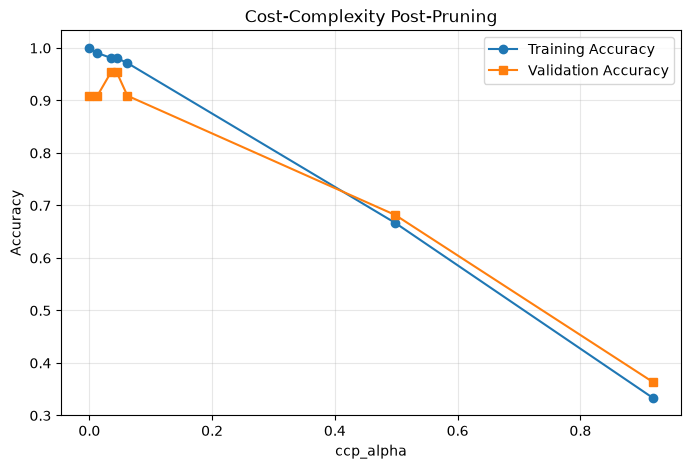

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(
    pruning_table["ccp_alpha"],
    pruning_table["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)
plt.plot(
    pruning_table["ccp_alpha"],
    pruning_table["validation_accuracy"],
    marker="s",
    label="Validation Accuracy"
)
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Cost-Complexity Post-Pruning")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### **Pre-Pruning vs Post-Pruning**

| Aspect | Pre-Pruning | Post-Pruning |
|---|---|---|
| Applied | During growth | After growing a larger tree |
| Main idea | Prevent complexity early | Remove weak complexity later |
| Examples | `max_depth`, `min_samples_leaf` | `ccp_alpha` |
| Main risk | Stopping too early | Extra model-selection work |

Both approaches try to improve generalization.

# <font color='red'>**19. Regression Trees**</font>

A Regression Tree predicts a **continuous** target.

The recursive tree structure is similar to a Classification Tree, but class impurity is replaced by regression error.

For squared-error regression, a leaf commonly predicts the mean of the target values that reach it:

$$
\hat y_{\text{leaf}}
=
\frac{1}{N_{\text{leaf}}}
\sum_{i\in\text{leaf}}y_i.
$$

## **19.1 Regression Split Criterion**

Suppose a node contains targets $y_1,\ldots,y_N$.

The node mean is

$$
\bar y
=
\frac{1}{N}\sum_{i=1}^{N}y_i.
$$

Its Sum of Squared Errors is

$$
SSE(S)
=
\sum_{i=1}^{N}(y_i-\bar y)^2.
$$

For a candidate split,

$$
SSE_{\text{split}}
=
SSE(S_L)+SSE(S_R).
$$

The improvement is

$$
\Delta SSE
=
SSE(S)-SSE_{\text{split}}.
$$

The preferred split minimizes child error, or equivalently maximizes the reduction in squared error.

## **19.2 Worked Regression Example**

Consider:

| $x$ | $y$ |
|---:|---:|
| 1 | 2 |
| 2 | 3 |
| 3 | 3 |
| 4 | 8 |
| 5 | 9 |
| 6 | 10 |

Candidate thresholds are

$$
1.5,\;2.5,\;3.5,\;4.5,\;5.5.
$$

For each threshold, we compute:

1. left-node mean,
2. right-node mean,
3. left SSE,
4. right SSE,
5. total split SSE,
6. SSE reduction.

In [33]:
reg_example = pd.DataFrame({
    "x": [1, 2, 3, 4, 5, 6],
    "y": [2, 3, 3, 8, 9, 10]
})

reg_example

,x,y
0,1,2
1,2,3
2,3,3
3,4,8
4,5,9
5,6,10


In [34]:
def sse(y):
    y = np.asarray(y, dtype=float)
    if len(y) == 0:
        return 0.0
    return np.sum((y - y.mean()) ** 2)

x_reg = reg_example["x"].to_numpy()
y_reg = reg_example["y"].to_numpy()

candidate_thresholds = (
    np.sort(np.unique(x_reg))[:-1]
    + np.sort(np.unique(x_reg))[1:]
) / 2

parent_sse = sse(y_reg)

rows = []
for threshold in candidate_thresholds:
    left_y = y_reg[x_reg <= threshold]
    right_y = y_reg[x_reg > threshold]

    split_sse = sse(left_y) + sse(right_y)

    rows.append({
        "Threshold": threshold,
        "Left Mean": left_y.mean(),
        "Right Mean": right_y.mean(),
        "Left SSE": sse(left_y),
        "Right SSE": sse(right_y),
        "Split SSE": split_sse,
        "SSE Reduction": parent_sse - split_sse
    })

reg_split_table = pd.DataFrame(rows)
reg_split_table

,Threshold,Left Mean,Right Mean,Left SSE,Right SSE,Split SSE,SSE Reduction
0,1.5,2.000000,6.6,0.000000,45.2,45.200000,17.633333
1,2.5,2.500000,7.5,0.500000,29.0,29.500000,33.333333
2,3.5,2.666667,9.0,0.666667,2.0,2.666667,60.166667
3,4.5,4.000000,9.5,22.000000,0.5,22.500000,40.333333
4,5.5,5.000000,10.0,42.000000,0.0,42.000000,20.833333


In [35]:
best_reg_split = reg_split_table.loc[
    reg_split_table["SSE Reduction"].idxmax()
]

print("Parent mean:", round(y_reg.mean(), 4))
print("Parent SSE :", round(parent_sse, 4))
print("\nBest split:")
print(best_reg_split.to_string())

Parent mean: 5.8333
Parent SSE : 62.8333

Best split:
Threshold         3.500000
Left Mean         2.666667
Right Mean        9.000000
Left SSE          0.666667
Right SSE         2.000000
Split SSE         2.666667
SSE Reduction    60.166667


After the first split, each child predicts its own mean.

If a child still contains substantial target variation and another useful split exists, the same procedure repeats recursively.

This creates a **piecewise-constant prediction function**.

## **19.3 Regression Tree on a Real Dataset**

In [36]:
diabetes = load_diabetes(as_frame=True)

X_reg_full = diabetes.data
y_reg_full = diabetes.target

Xr_train, Xr_temp, yr_train, yr_temp = train_test_split(
    X_reg_full,
    y_reg_full,
    test_size=0.30,
    random_state=RANDOM_STATE
)

Xr_val, Xr_test, yr_val, yr_test = train_test_split(
    Xr_temp,
    yr_temp,
    test_size=0.50,
    random_state=RANDOM_STATE
)

reg_tree = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=4,
    random_state=RANDOM_STATE
)

reg_tree.fit(Xr_train, yr_train)
reg_val_pred = reg_tree.predict(Xr_val)

print(f"Validation MSE  = {mean_squared_error(yr_val, reg_val_pred):.4f}")
print(f"Validation RMSE = {np.sqrt(mean_squared_error(yr_val, reg_val_pred)):.4f}")
print(f"Validation MAE  = {mean_absolute_error(yr_val, reg_val_pred):.4f}")
print(f"Validation R2   = {r2_score(yr_val, reg_val_pred):.4f}")
print("Depth           =", reg_tree.get_depth())
print("Leaves          =", reg_tree.get_n_leaves())

Validation MSE  = 3293.5130
Validation RMSE = 57.3891
Validation MAE  = 44.6891
Validation R2   = 0.3560
Depth           = 4
Leaves          = 16


In [37]:
reg_depth_rows = []

for depth in range(1, 11):
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=RANDOM_STATE
    )
    model.fit(Xr_train, yr_train)

    train_pred = model.predict(Xr_train)
    val_pred = model.predict(Xr_val)

    reg_depth_rows.append({
        "max_depth": depth,
        "train_RMSE": np.sqrt(
            mean_squared_error(yr_train, train_pred)
        ),
        "validation_RMSE": np.sqrt(
            mean_squared_error(yr_val, val_pred)
        ),
        "validation_R2": r2_score(yr_val, val_pred)
    })

reg_depth_table = pd.DataFrame(reg_depth_rows)
reg_depth_table

,max_depth,train_RMSE,validation_RMSE,validation_R2
0,1,65.673392,62.262829,0.241926
1,2,58.672457,54.364535,0.422056
2,3,54.022909,56.413441,0.377672
3,4,49.502589,57.389136,0.355959
4,5,44.336431,59.778093,0.301224
5,6,39.268790,62.767942,0.229576
6,7,34.663543,68.651757,0.078368
7,8,27.451797,73.055210,-0.043654
8,9,22.111302,74.895285,-0.096890
9,10,17.376092,72.935494,-0.040236


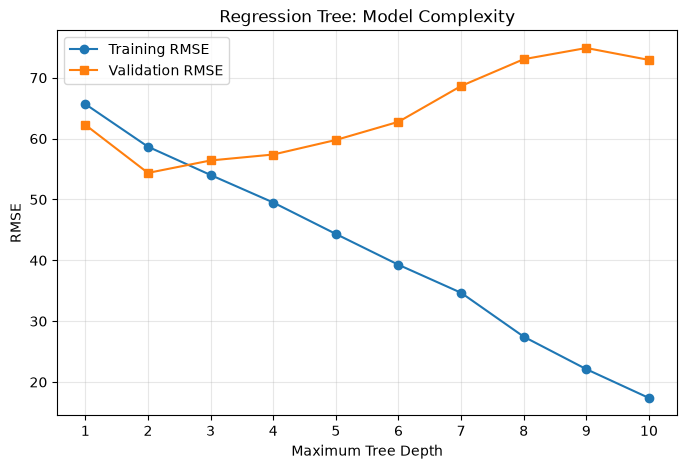

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(
    reg_depth_table["max_depth"],
    reg_depth_table["train_RMSE"],
    marker="o",
    label="Training RMSE"
)
plt.plot(
    reg_depth_table["max_depth"],
    reg_depth_table["validation_RMSE"],
    marker="s",
    label="Validation RMSE"
)
plt.xlabel("Maximum Tree Depth")
plt.ylabel("RMSE")
plt.title("Regression Tree: Model Complexity")
plt.xticks(reg_depth_table["max_depth"])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# <font color='red'>**Consolidated Summary**</font>

| Topic | Main idea |
|---|---|
| Gini impurity | $1-\sum p_k^2$ |
| Entropy | $-\sum p_k\log_2p_k$ |
| Information Gain | Parent Entropy minus weighted child Entropy |
| Numerical split | Search thresholds such as $x_j\le t$ |
| Categorical split | Partition by category/category groups |
| Leaf in classification | Majority class / class probabilities |
| Regression split | Reduce squared error |
| Leaf in regression | Mean target value |
| Pre-pruning | Restrict growth while fitting |
| Post-pruning | Remove weak branches afterward |
| Univariate tree | One feature per split |
| Multivariate tree | Linear combination of features per split |

---

# <font color='purple'>**Part B — Laboratory Assignment**</font>

# <font color='purple'>**Assignment 4: Decision Trees — Classification, Pruning and Regression**</font>

### **Objective**

Apply Decision Tree learning using **Gini impurity** and **Information Gain (Entropy-based)**, implement the core classifier from scratch, study categorical and numerical splitting, investigate pruning, and extend the analysis to Regression Trees.

### **Datasets**

- **Classification:** `sklearn.datasets.load_breast_cancer()`
- **Regression:** `sklearn.datasets.load_diabetes()`
- **Categorical mini-task:** supplied directly in this notebook

### **Total Marks: 20**

Use `random_state=42` wherever applicable.

> **Restriction:** `DecisionTreeClassifier` must not be used to build the scratch classifier in Tasks 3–6. It may be used from Task 8 onward where explicitly requested.

## <font color='blue'>**Task 1: Load and Inspect the Classification Dataset**</font> **[Mark - 1]**

Load the Breast Cancer Wisconsin dataset and report:

- first five observations;
- dataset shape;
- feature names;
- target names;
- class counts and percentages;
- missing-value count.

Identify the majority class.

In [39]:
# Task 1
# Write your code here.

## <font color='blue'>**Task 2: Train–Validation–Test Split**</font> **[Mark - 1]**

Create **stratified** partitions:

$$
70\% : 15\% : 15\%.
$$

Report:

- number of observations in each set;
- class proportions in each set.

In one or two sentences, explain why standardization is generally unnecessary for an ordinary Decision Tree.

In [40]:
# Task 2
# Write your code here.

## <font color='blue'>**Task 3: Gini, Entropy and Information Gain from Scratch**</font> **[Marks - 3]**

Without using a tree library, implement:

1. class-probability calculation;
2. Gini impurity;
3. Entropy;
4. weighted child impurity;
5. Gini impurity reduction;
6. Information Gain.

Use

$$
G(S)=1-\sum_kp_k^2,
$$

$$
H(S)=-\sum_kp_k\log_2p_k,
$$

and

$$
IG
=
H(S)
-
\frac{|S_L|}{|S|}H(S_L)
-
\frac{|S_R|}{|S|}H(S_R).
$$

Verify the functions using at least:

- one **pure** manually created label vector;
- one **mixed** manually created label vector.

Show the calculated results.

In [41]:
# Task 3
# Write your code here.

## <font color='blue'>**Task 4: Implement a Numerical Decision Tree Classifier from Scratch**</font> **[Marks - 5]**

Implement your own binary Decision Tree classifier.

It must support both:

```python
criterion="gini"
```

and

```python
criterion="information_gain"
```

For `information_gain`, use Entropy as the node impurity.

Your implementation must:

1. generate candidate thresholds for numerical features;
2. examine feature-threshold pairs;
3. calculate split quality;
4. select the best split;
5. recursively create child nodes;
6. stop at pure nodes;
7. support `max_depth`;
8. support `min_samples_split`;
9. support `min_samples_leaf`;
10. use majority class prediction at a leaf;
11. implement `fit(X, y)`;
12. implement `predict(X)`.

You may create helper structures/functions such as:

```python
Node
_best_split()
_grow_tree()
_traverse_tree()
```

or equivalent components.

In [42]:
# Task 4
# Write your scratch Decision Tree implementation here.

## <font color='blue'>**Task 5: Compare Gini and Information Gain**</font> **[Marks - 2]**

Using the same training data and the same pre-pruning settings, train:

```python
criterion="gini"
```

and

```python
criterion="information_gain"
```

Report for both models:

- training accuracy;
- validation accuracy;
- validation Macro F1-score.

Also report:

- number of validation predictions on which the two models disagree.

Briefly discuss whether changing the criterion materially changes the predictions.

In [43]:
# Task 5
# Write your code here.

## <font color='blue'>**Task 6: Pre-Pruning Experiment**</font> **[Marks - 2]**

Using your scratch tree, study

$$
\texttt{max\_depth}
\in
\{1,2,3,4,5,6,7,8\}.
$$

For each depth, report:

- training accuracy;
- validation accuracy.

Plot both curves.

Then perform **one additional pre-pruning experiment** using either:

- `min_samples_split`, or
- `min_samples_leaf`.

Select the final pre-pruning settings using validation data only.

Explain briefly:

- where underfitting appears;
- whether deeper trees show signs of overfitting;
- why training accuracy alone should not be used for model selection.

In [44]:
# Task 6
# Write your code here.

## <font color='blue'>**Task 7: Categorical Split to Leaf Nodes**</font> **[Marks - 2]**

Use the following categorical dataset.

In [45]:
categorical_assignment_df = pd.DataFrame({
    "Weather": [
        "Sunny", "Sunny", "Cloudy", "Rainy",
        "Rainy", "Cloudy", "Sunny", "Rainy"
    ],
    "Wind": [
        "Weak", "Strong", "Weak", "Weak",
        "Strong", "Strong", "Weak", "Strong"
    ],
    "Traffic": [
        "High", "High", "Low", "Low",
        "High", "Low", "Low", "High"
    ],
    "Go_Out": [
        "No", "No", "Yes", "Yes",
        "No", "Yes", "Yes", "No"
    ]
})

categorical_assignment_df

,Weather,Wind,Traffic,Go_Out
0,Sunny,Weak,High,No
1,Sunny,Strong,High,No
2,Cloudy,Weak,Low,Yes
3,Rainy,Weak,Low,Yes
4,Rainy,Strong,High,No
5,Cloudy,Strong,Low,Yes
6,Sunny,Weak,Low,Yes
7,Rainy,Strong,High,No


Without using a Decision Tree library:

1. Calculate the parent Entropy.
2. Calculate Information Gain for every categorical feature.
3. Select the root feature.
4. Inspect each branch.
5. Split every impure branch again when possible.
6. Draw the final tree using Markdown/text.
7. Clearly identify all leaf predictions.

Show all intermediate calculations.

In [46]:
# Task 7
# Write your calculations/code here.

## <font color='blue'>**Task 8: Post-Pruning with Cost Complexity**</font> **[Mark - 2]**

Now Scikit-learn may be used.

Train an initially unrestricted `DecisionTreeClassifier`.

Obtain:

```python
cost_complexity_pruning_path()
```

Then train models across candidate `ccp_alpha` values.

Plot:

- training accuracy versus `ccp_alpha`;
- validation accuracy versus `ccp_alpha`.

Select an appropriate `ccp_alpha` using validation performance.

Report the selected tree's:

- depth;
- number of leaves;
- validation accuracy.

In [47]:
# Task 8
# Write your code here.

## <font color='blue'>**Task 9: Regression Tree**</font> **[Marks - 2]**

Use `load_diabetes()`.

1. Create 70% / 15% / 15% train-validation-test partitions.
2. Train `DecisionTreeRegressor` for several values of `max_depth`.
3. Select the depth using validation RMSE.
4. Evaluate the selected model on the untouched test set.

Report:

- RMSE;
- MAE;
- $R^2$;
- fitted depth;
- number of leaves.

Also explain why the squared-error Regression Tree typically predicts the **mean target value** at a leaf.

In [48]:
# Task 9
# Write your code here.

## **Marks Distribution**

| Task | Component | Marks |
|---:|---|---:|
| 1 | Dataset inspection | 1 |
| 2 | Train-validation-test split | 1 |
| 3 | Gini, Entropy and Information Gain | 3 |
| 4 | Scratch Decision Tree classifier | 5 |
| 5 | Gini vs Information Gain | 2 |
| 6 | Pre-pruning experiment | 2 |
| 7 | Categorical split to leaf nodes | 2 |
| 8 | Post-pruning | 2 |
| 9 | Regression Tree | 2 |

|  | **Total** | **20** |